# mHealth EDA Overview

## ガードレール（必須）
- 目的: mHealthログの分布・品質把握、activity/subject偏りの確認
- データ仕様: mHealth `.log`（空白区切り、24列、最後が `activity_label`）
- 禁止事項: 勝手な外れ値除外、リークにつながる時系列混在
- 出力条件: seed固定（再現性のため）、成果物は `analysis/reports/eda/`
- 検証: 行数・合計の検算ログを出力


In [1]:
from pathlib import Path
import json
import math
import os
import re
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(42)

cwd = Path.cwd().resolve()
project_root = next(p for p in [cwd, *cwd.parents] if (p / "pyproject.toml").exists())

input_dir = project_root / "data"
output_dir = project_root / "reports" / "eda"
output_dir.mkdir(parents=True, exist_ok=True)
input_dir, output_dir


(PosixPath('/workspaces/data-flow/analysis/data'),
 PosixPath('/workspaces/data-flow/analysis/reports/eda'))

In [2]:
# 列名は基盤の変換ロジックに準拠
COLUMN_NAMES = [
    'chest_acc_x', 'chest_acc_y', 'chest_acc_z',
    'chest_ecg_1', 'chest_ecg_2',
    'left_ankle_acc_x', 'left_ankle_acc_y', 'left_ankle_acc_z',
    'left_ankle_gyro_x', 'left_ankle_gyro_y', 'left_ankle_gyro_z',
    'left_ankle_mag_x', 'left_ankle_mag_y', 'left_ankle_mag_z',
    'right_lower_arm_acc_x', 'right_lower_arm_acc_y', 'right_lower_arm_acc_z',
    'right_lower_arm_gyro_x', 'right_lower_arm_gyro_y', 'right_lower_arm_gyro_z',
    'right_lower_arm_mag_x', 'right_lower_arm_mag_y', 'right_lower_arm_mag_z',
    'activity_label',
]

SUBJECT_PATTERN = re.compile(r'mHealth_subject(\d+)\.log$', re.IGNORECASE)


In [3]:
def find_log_files(root: Path) -> list[Path]:
    return sorted([p for p in root.iterdir() if p.name.lower().startswith('mhealth_subject') and p.suffix == '.log'])

def extract_subject_id(path: Path) -> int:
    match = SUBJECT_PATTERN.search(path.name)
    if not match:
        raise ValueError(f'Could not extract subject_id from {path}')
    return int(match.group(1))

def init_stats():
    stats = {}
    for col in COLUMN_NAMES:
        stats[col] = {
            'count': 0.0,
            'missing': 0.0,
            'sum': 0.0,
            'sumsq': 0.0,
            'min': math.inf,
            'max': -math.inf,
        }
    return stats

def update_stats(stats, chunk: pd.DataFrame):
    numeric = chunk[COLUMN_NAMES]
    counts = len(numeric)
    sums = numeric.sum(skipna=True)
    sums_sq = (numeric * numeric).sum(skipna=True)
    mins = numeric.min(skipna=True)
    maxs = numeric.max(skipna=True)
    missing = numeric.isna().sum()

    for col in COLUMN_NAMES:
        stats[col]['count'] += counts
        stats[col]['missing'] += float(missing[col])
        stats[col]['sum'] += float(sums[col])
        stats[col]['sumsq'] += float(sums_sq[col])
        stats[col]['min'] = min(stats[col]['min'], float(mins[col]))
        stats[col]['max'] = max(stats[col]['max'], float(maxs[col]))

def finalize_stats(stats) -> pd.DataFrame:
    rows = []
    for col, values in stats.items():
        count = values['count']
        mean = values['sum'] / count if count else float('nan')
        variance = (values['sumsq'] / count - mean**2) if count else float('nan')
        std = math.sqrt(variance) if count else float('nan')
        rows.append({
            'column': col,
            'count': int(count),
            'missing': int(values['missing']),
            'mean': mean,
            'std': std,
            'min': values['min'],
            'max': values['max'],
            'sum': values['sum'],
        })
    return pd.DataFrame(rows)


In [4]:
log_files = find_log_files(input_dir)
log_files


[PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject1.log'),
 PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject10.log'),
 PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject2.log'),
 PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject3.log'),
 PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject4.log'),
 PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject5.log'),
 PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject6.log'),
 PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject7.log'),
 PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject8.log'),
 PosixPath('/workspaces/data-flow/analysis/data/mHealth_subject9.log')]

In [5]:
chunksize = 200_000
stats = init_stats()
activity_counts = Counter()
subject_counts = Counter()
subject_activity_counts = defaultdict(Counter)
total_rows = 0

for path in log_files:
    subject_id = extract_subject_id(path)
    for chunk in pd.read_csv(path, sep=r'\s+', header=None, names=COLUMN_NAMES, chunksize=chunksize):
        update_stats(stats, chunk)
        total_rows += len(chunk)
        subject_counts[subject_id] += len(chunk)
        activity_counts.update(chunk['activity_label'].value_counts().to_dict())
        subject_activity_counts[subject_id].update(chunk['activity_label'].value_counts().to_dict())

stats_df = finalize_stats(stats)
stats_df.to_csv(output_dir / 'basic_stats.csv', index=False)

activity_df = (
    pd.DataFrame([{'activity_label': k, 'count': v} for k, v in activity_counts.items()])
    .sort_values('activity_label')
)
activity_df.to_csv(output_dir / 'activity_counts.csv', index=False)

subject_df = (
    pd.DataFrame([{'subject_id': k, 'count': v} for k, v in subject_counts.items()])
    .sort_values('subject_id')
)
subject_df.to_csv(output_dir / 'subject_counts.csv', index=False)

subject_activity_df = (
    pd.DataFrame(subject_activity_counts).fillna(0).astype(int).sort_index(axis=0).sort_index(axis=1)
)
subject_activity_df.to_csv(output_dir / 'subject_activity_counts.csv')

checksums = {
    'total_rows': total_rows,
    'sum_by_column': stats_df.set_index('column')['sum'].to_dict(),
}
(output_dir / 'checksums.json').write_text(json.dumps(checksums, indent=2, sort_keys=True))

total_rows


1215745

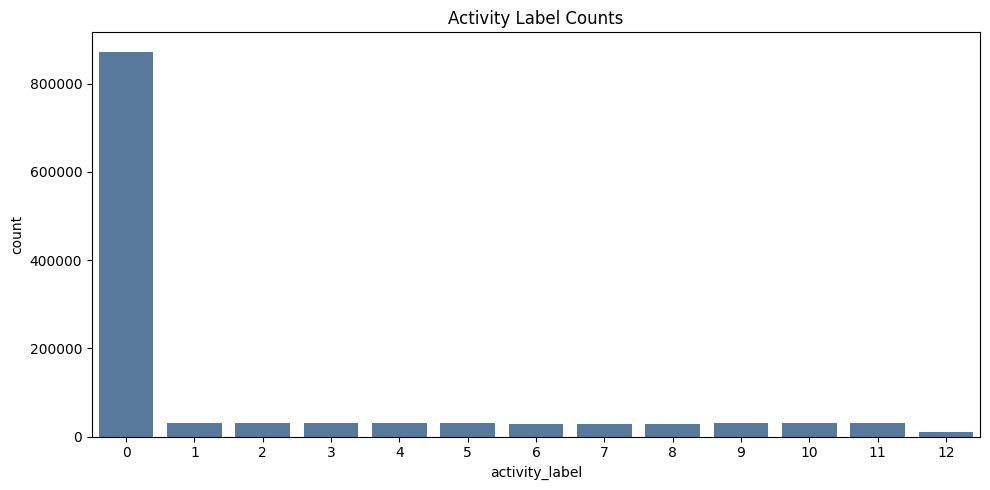

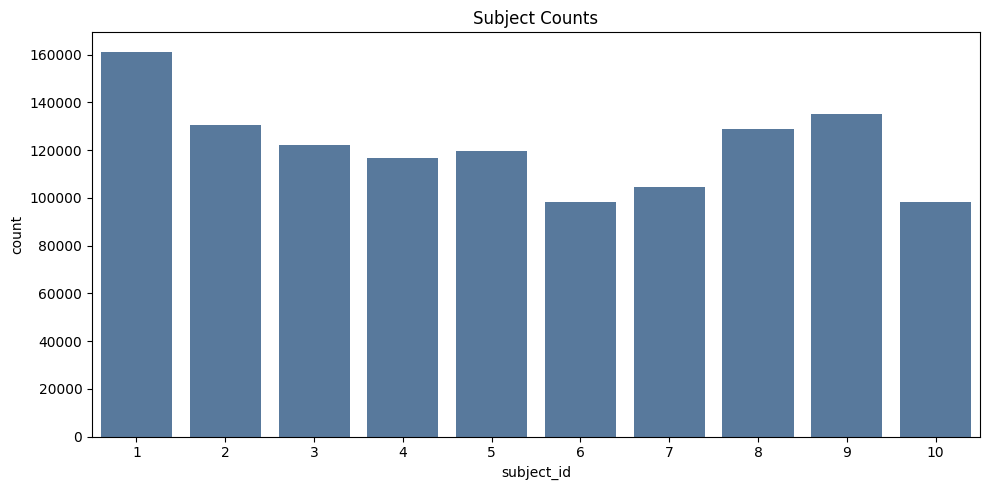

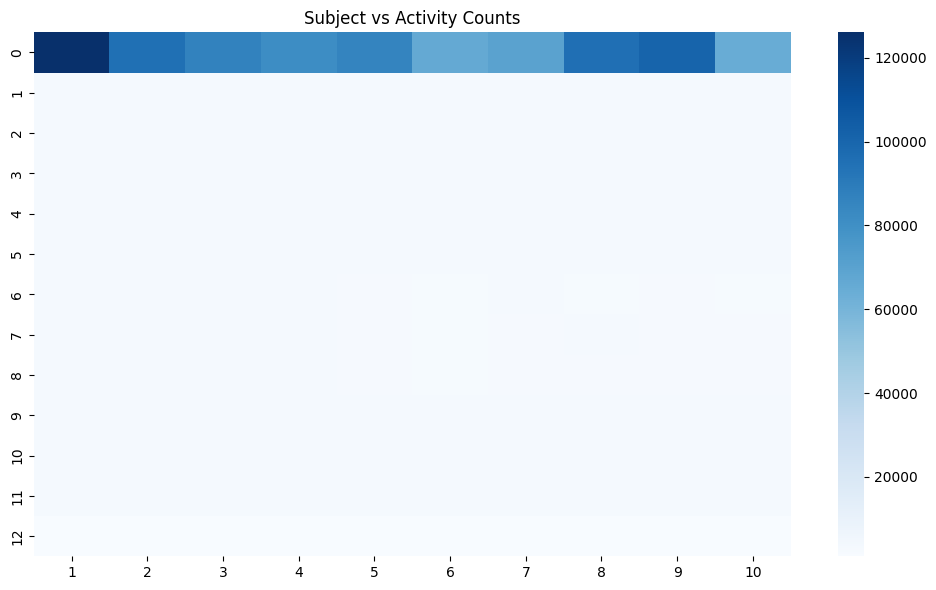

'plots saved'

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(data=activity_df, x='activity_label', y='count', color='#4C78A8')
plt.title('Activity Label Counts')
plt.tight_layout()
plt.savefig(output_dir / 'activity_counts.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(10, 5))
sns.barplot(data=subject_df, x='subject_id', y='count', color='#4C78A8')
plt.title('Subject Counts')
plt.tight_layout()
plt.savefig(output_dir / 'subject_counts.png', dpi=150)
plt.show()
plt.close()

plt.figure(figsize=(10, 6))
sns.heatmap(subject_activity_df, cmap='Blues', cbar=True)
plt.title('Subject vs Activity Counts')
plt.tight_layout()
plt.savefig(output_dir / 'subject_activity_heatmap.png', dpi=150)
plt.show()
plt.close()
'plots saved'


In [8]:
stats_df.head()


,column,count,missing,mean,std,min,max,sum
0,chest_acc_x,1215745,0,-8.522361,4.075291,-22.4380,19.0940,-1.036102e+07
1,chest_acc_y,1215745,0,-0.214001,2.138954,-20.1880,20.9270,-2.601710e+05
2,chest_acc_z,1215745,0,-1.055950,3.574162,-18.4010,26.1960,-1.283765e+06
3,chest_ecg_1,1215745,0,-0.005122,0.746597,-8.6196,8.5149,-6.227536e+03
4,chest_ecg_2,1215745,0,-0.004506,0.727039,-8.6196,8.5191,-5.478675e+03


In [9]:
activity_df.sort_values('count', ascending=False).head()


,activity_label,count
0,0,872550
2,1,30720
3,2,30720
4,3,30720
5,4,30720


In [10]:
subject_df.sort_values('count', ascending=False).head()


,subject_id,count
0,1,161280
9,9,135168
2,2,130561
8,8,129024
3,3,122112


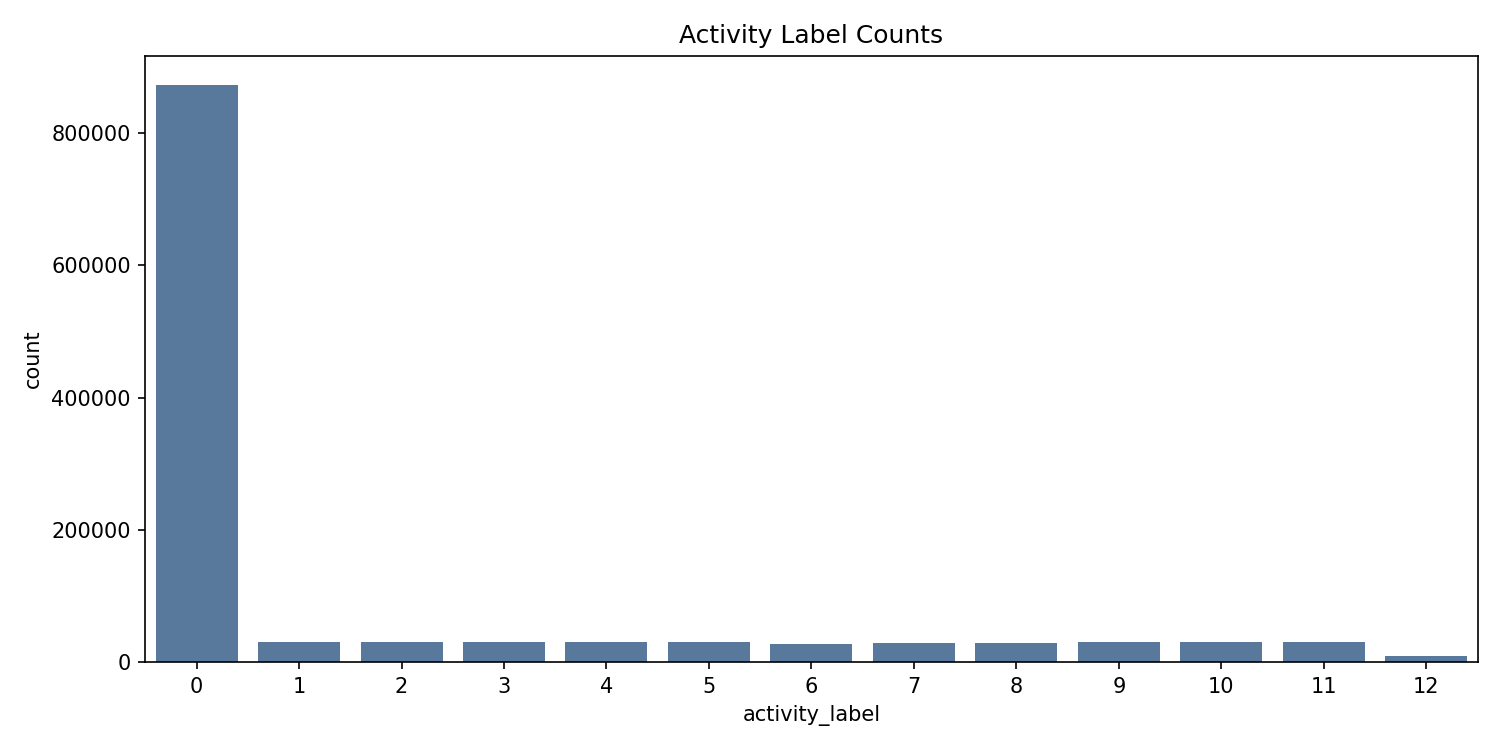

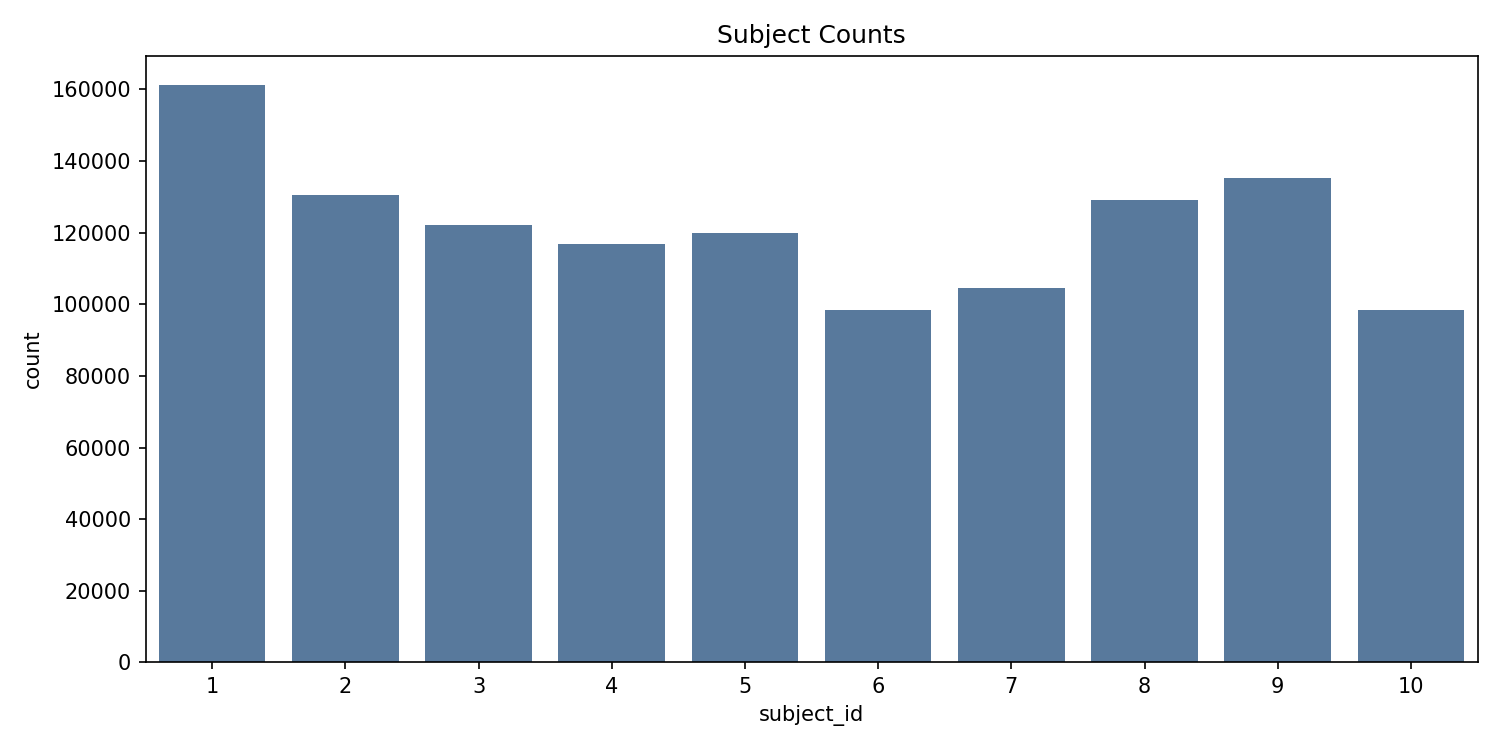

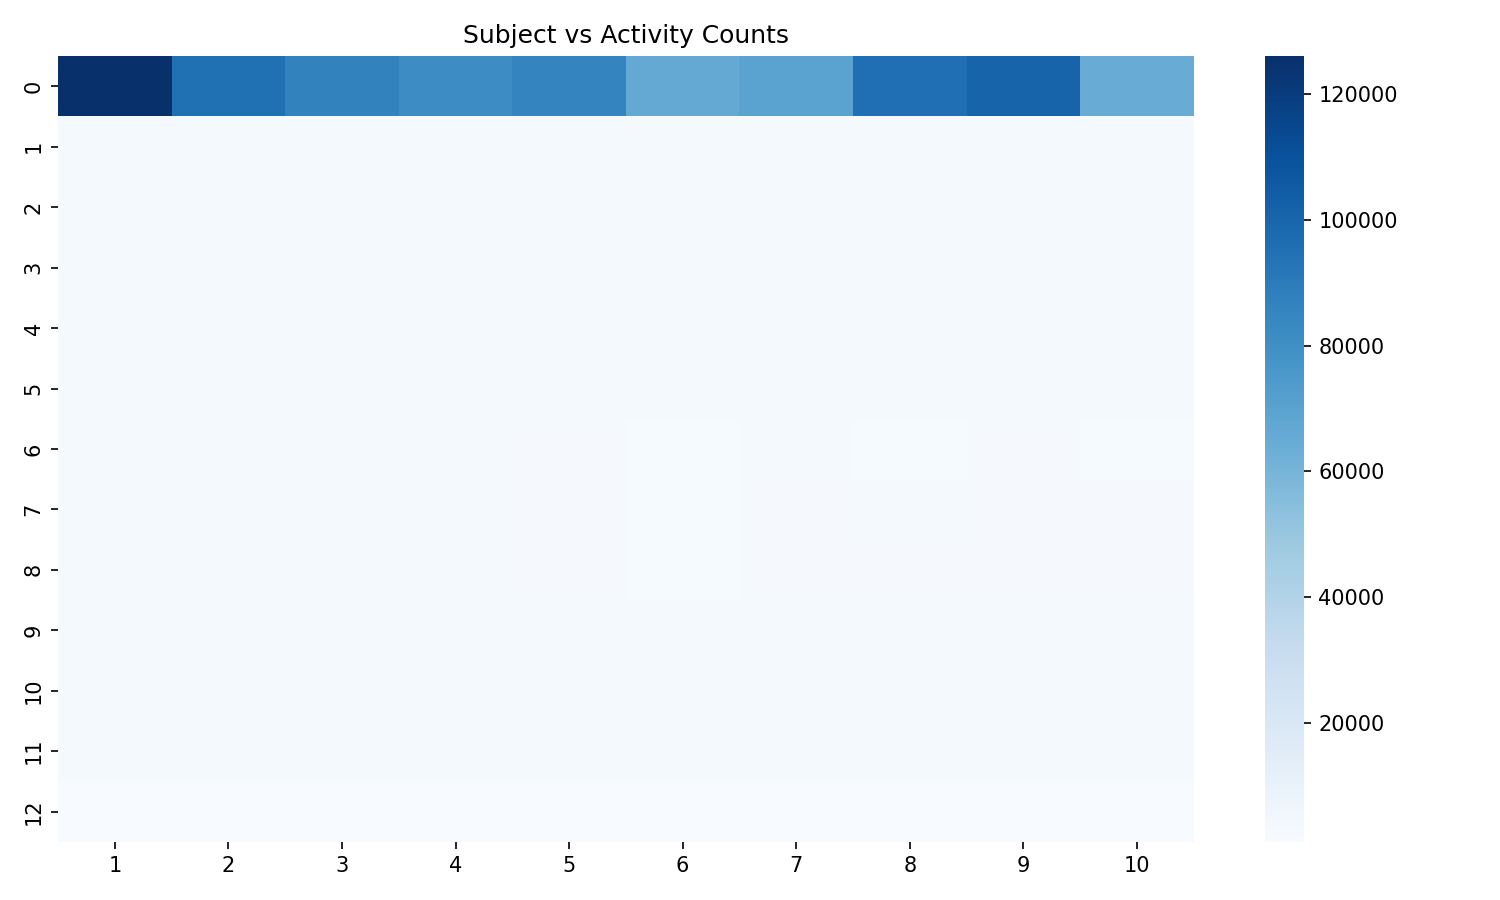

In [11]:
from IPython.display import Image, display

display(Image(filename=str(output_dir / 'activity_counts.png')))
display(Image(filename=str(output_dir / 'subject_counts.png')))
display(Image(filename=str(output_dir / 'subject_activity_heatmap.png')))
